This project analyzes the trends, policy impact, and economic implications of Hong Kong’s Old Age Living Allowance (OALA) from 2013 to 2024, using public data and Python-based analysis. There are three phases of Old Age Living Allowance, including phase 1 from 2013 to 2017, phase 2 from 2018 to 2021 and phase 3 from 2022 to 2024.

In phase 1, there is only one allowance amount introduced in 2013. In phase 2, Higher Old Age Living Allowance introduced in 2018. There are both Normal Old Age Living Allowance and Higher Old Age Living Allowance. In phase 3, two allowances has transformed into Unified Old Age Living Allowance.

In [299]:
!pip install pandas
import pandas as pd

In [300]:
import os 
os.chdir('/Users/chenzili/comp1025')

In [301]:
df=pd.read_csv("Project/Persons_of_Receiving_OALA.csv")
rows=[4,16,17]
columns=[10,15,16]+list(range(22,34))
df=df.iloc[rows,columns]
df.to_csv("Project/persons_receiving_oala_2013_to_2024.csv", index= False) 
df

,Unnamed: 10,Unnamed: 15,Unnamed: 16,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31,Unnamed: 32,Unnamed: 33
4,Type,性別,Sex,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
16,Old Age Living Allowance[2],女,F,232 568,234 310,244 694,253 697,272 060,305 444,324 062,343 946,363 113,387 990,413 163,434 644
17,NaN,男,M,177 475,177 981,184 550,189 235,202 255,227 056,238 952,253 937,267 848,286 745,306 710,322 427


In [302]:
#Calculation of total number of OALA recipients from 2023 to 2024
df2= pd.read_csv("Project/persons_receiving_oala_2013_to_2024.csv")

years = list(range(2013,2025))
totals = (df2.iloc[1, 3:].str.replace(" ", "").astype(int) + 
          df2.iloc[2, 3:].str.replace(" ", "").astype(int)).tolist()

df2= pd.DataFrame({"Year": years,"Persons_Receiving_OALA": totals})

df2.to_csv("Project/total_persons_receiving_oala_2013_to_2024.csv",index=False)
df2

,Year,Persons_Receiving_OALA
0,2013,410043
1,2014,412291
2,2015,429244
3,2016,442932
4,2017,474315
5,2018,532500
6,2019,563014
7,2020,597883
8,2021,630961
9,2022,674735


In [303]:
#Extracting data related to population of 65 years old or above from 2013 to 2024
df3=pd.read_csv("Project/population.csv")
rows=[3,4,5] + list(range(57, 63))
columns=[0,1]+list(range(106,130))
df3=df3.iloc[rows,columns]
df3

,Table 110-01001 : Population by Sex and Age Group,Unnamed: 1,Unnamed: 106,Unnamed: 107,Unnamed: 108,Unnamed: 109,Unnamed: 110,Unnamed: 111,Unnamed: 112,Unnamed: 113,...,Unnamed: 120,Unnamed: 121,Unnamed: 122,Unnamed: 123,Unnamed: 124,Unnamed: 125,Unnamed: 126,Unnamed: 127,Unnamed: 128,Unnamed: 129
3,Year,NaN,2013,2013,2014,2014,2015,2015,2016,2016,...,2020,2020,2021,2021,2022,2022,2023,2023,2024,2024
4,Reference time-point,NaN,Mid-year,Year-end,Mid-year,Year-end,Mid-year,Year-end,Mid-year,Year-end,...,Mid-year,Year-end,Mid-year,Year-end,Mid-year,Year-end,Mid-year,Year-end,Mid-year,Year-end
5,Sex,Age group,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
57,Both sexes,65 - 69,295.1,312.0,326.3,346.9,363.1,383.2,395.7,405.1,...,465.9,475.6,492.2,508.3,523.5,548.5,568.5,581.4,584.7,590.9
58,Both sexes,70 - 74,213.1,209.9,211.5,213.6,213.7,215.5,220.8,236.0,...,342.5,359.4,370.8,381.4,395.0,413.4,424.8,434.1,442.4,451.2
59,Both sexes,75 - 79,210.2,210.4,209.3,209.9,209.5,210.4,206.4,201.2,...,184.8,188.2,197.1,209.5,221.1,239.4,254.1,273.4,290.9,310.4
60,Both sexes,80 - 84,157.6,163.4,164.7,167.7,166.2,165.6,167.0,169.9,...,170.1,169.8,165.2,162.2,159.3,158.2,158.6,156.0,157.7,158.9
61,Both sexes,≥85,143.9,150.6,152.0,157.6,162.1,171.6,173.3,180.6,...,218.1,224.3,226.2,233.7,230.0,235.2,235.9,244.2,243.2,249.7
62,Both sexes,All age groups,7178.9,7210.9,7229.5,7252.9,7291.3,7309.7,7336.6,7378.1,...,7481.0,7426.7,7413.1,7401.5,7346.1,7472.6,7536.1,7527.9,7524.1,7500.6


In [304]:
#Saving the extracted data into CSV dataframe
df3.to_csv("Project/population_of_elders_2013_to_2024.csv",index=False)


Number of OALA recipients are year-end figures which is on 31 December of each year. When we use year-end population to calculate the percentage, the time point is perfectly aligned with the OALA recipient data, so the resulting "percentage of the elderly population" will be more accurate.

In [305]:
#Calculation of total number of elders from 2013 to 2024
df4=pd.read_csv("Project/population_of_elders_2013_to_2024.csv")

df4=pd.DataFrame({
    "Year": range(2013, 2025),
    "Population_aged_65_and_above": (
        df3.iloc[3:8, 3::2].astype(float).sum(axis=0) * 1000
    ).round(0).astype(int).values
})

df4.to_csv("Project/total_elder_population_2013_to_2024.csv", index=False)
df4

,Year,Population_aged_65_and_above
0,2013,1046300
1,2014,1095700
2,2015,1146300
3,2016,1192800
4,2017,1246700
5,2018,1305300
6,2019,1359500
7,2020,1417300
8,2021,1495100
9,2022,1594700


In [328]:
import matplotlib.pyplot as plt

In [329]:
df4=pd.read_csv("Project/total_elder_population_2013_to_2024.csv")
df2=pd.read_csv("Project/total_persons_receiving_oala_2013_to_2024.csv")

In [330]:
# Merge the two datasets on Year
df=pd.merge(df2, df4, on="Year")

In [331]:
# Filter for the period 2013 to 2017 only
df_plot = df[df['Year'].between(2013, 2017)].copy()


In [332]:
# Calculate the percentage of elderly population receiving OALA
df_plot['Percentage'] = (
    df_plot['Persons_Receiving_OALA'] / 
    df_plot['Population_aged_65_and_above'] * 100
).round(2)


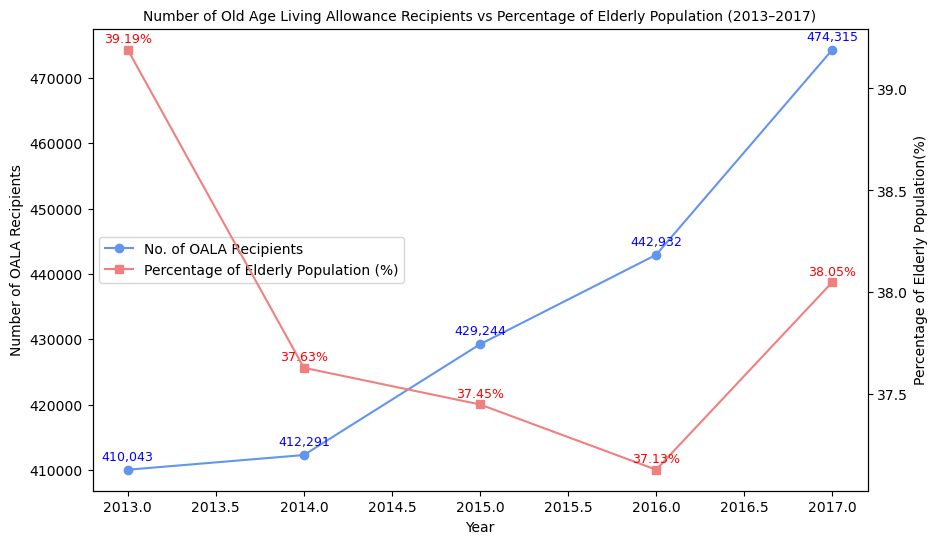

In [396]:
# Create a dual‑axis line chart
fig, ax1 = plt.subplots(figsize=(10,6))


# Left axis: number of recipients (blue)
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of OALA Recipients')
ax1.plot(df_plot['Year'], df_plot['Persons_Receiving_OALA'],
         marker='o', color='cornflowerblue', label='No. of OALA Recipients')


# Right axis: percentage of elderly population (red)
ax2 = ax1.twinx()
ax2.set_ylabel('Percentage of Elderly Population(%)')
ax2.plot(df_plot['Year'], df_plot['Percentage'],
         marker='s', color='lightcoral', label='Percentage of Elderly Population (%)')


# Title
plt.title('Number of Old Age Living Allowance Recipients vs Percentage of Elderly Population (2013–2017)', fontsize=10)

# Add simple data labels
for i, row in df_plot.iterrows():
    ax1.annotate(f"{int(row['Persons_Receiving_OALA']):,}",
                 xy=(row['Year'], row['Persons_Receiving_OALA']),
                 xytext=(0, 7), textcoords='offset points',
                 ha='center', fontsize=9, color='blue')
    
    ax2.annotate(f"{row['Percentage']}%",
                 xy=(row['Year'], row['Percentage']),
                 xytext=(0, 5), textcoords='offset points',  
                 ha='center', fontsize=9, color='red')
# Add legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc= 'center left', fontsize=10)
    
plt.show()

Since the Old Age Living Allowance(OALA) has been introduced in 2013, the percentage of OALA recipients ranged from 39.19% to 37.13% from 2013 to 2017, taking account of more than one-third of the population. After the asset limits having been increased in March of 2017, there was rise of 0.92 percentage points of OALA recipients percentage.

In [397]:
df_plot1 = df[df['Year'].between(2018, 2021)].copy()

In [398]:
df_plot1['Percentage'] = (df_plot1['Persons_Receiving_OALA'] / df_plot1['Population_aged_65_and_above'] * 100).round(2)

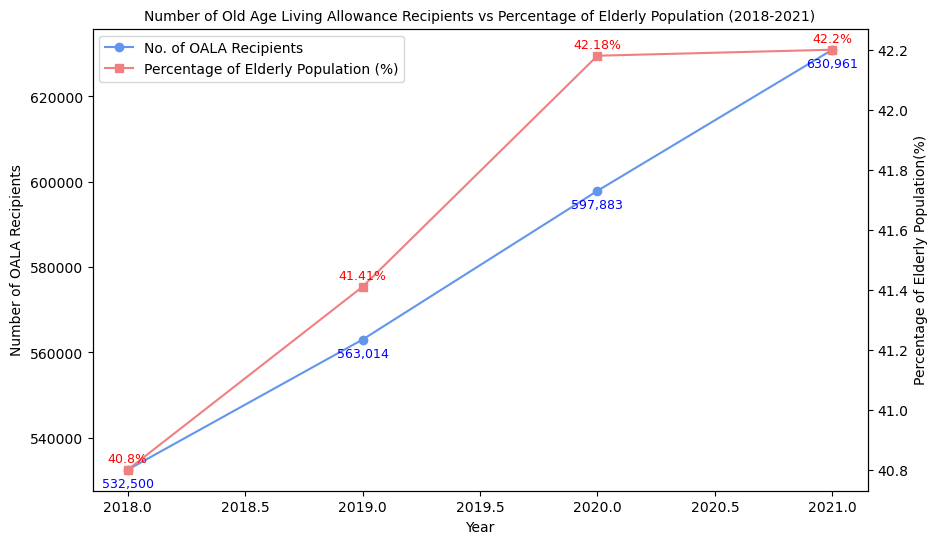

In [399]:
# Create a dual‑axis line chart
fig,ax1 = plt.subplots(figsize=(10,6))

# Left axis: number of recipients (blue)
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of OALA Recipients')
ax1.plot(df_plot1['Year'], df_plot1['Persons_Receiving_OALA'], marker='o', color='cornflowerblue', label='No. of OALA Recipients')

# Right axis: percentage of elderly population (red)
ax2 = ax1.twinx()
ax2.set_ylabel('Percentage of Elderly Population(%)')
ax2.plot(df_plot1['Year'], df_plot1['Percentage'], marker='s', color='lightcoral', label='Percentage of Elderly Population (%)')

#Title
plt.title('Number of Old Age Living Allowance Recipients vs Percentage of Elderly Population (2018-2021)', fontsize=10)

#Add data labels
for i, row in df_plot1.iterrows():
    ax1.annotate(f"{int(row['Persons_Receiving_OALA']):,}",
                 xy=(row['Year'], row['Persons_Receiving_OALA']),
                 xytext=(0,-13), textcoords='offset points',
                 ha= 'center', fontsize=9, color= 'blue')
    
    ax2.annotate(f"{row['Percentage']}%",
                 xy=(row['Year'], row['Percentage']),
                 xytext=(0,5), textcoords='offset points',
                 ha= 'center',fontsize=9, color= 'red')

#Add legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, lablels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 +lines2, labels1 + labels2, loc='upper left', fontsize=10)

plt.show()

After the introduction of Two-Tier System of Old Age Living Allowance, there were upward changes for percentage of elderly receiving the allowance, peaking at 42.2% at 2021.

In [400]:
df_plot2 = df[df['Year'].between(2022,2024)].copy()

In [401]:
df_plot2['Percentage']= (df_plot2['Persons_Receiving_OALA']/ df_plot2['Population_aged_65_and_above'] *100).round(2)

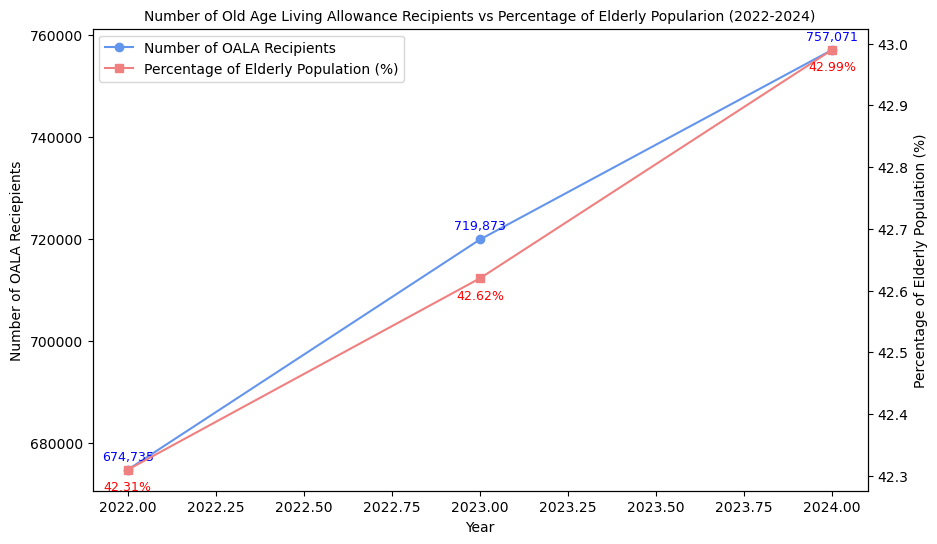

In [446]:
# Create a dual‑axis line chart
fig, ax1 = plt.subplots(figsize=(10,6))

# Left axis: number of recipients (blue)
ax1.set_xlabel('Year')
ax1.set_ylabel('Number of OALA Reciepients')
ax1.plot(df_plot2['Year'], df_plot2['Persons_Receiving_OALA'], marker='o', color='cornflowerblue', label='Number of OALA Recipients')

# Right axis: percentage of elderly population (%)
ax2 = ax1.twinx()
ax2.set_ylabel("Percentage of Elderly Population (%)")
ax2.plot(df_plot2['Year'], df_plot2['Percentage'], marker='s', color='lightcoral', label='Percentage of Elderly Population (%)')

#Title
plt.title("Number of Old Age Living Allowance Recipients vs Percentage of Elderly Popularion (2022-2024)", fontsize=10)

# Add simple data labels
for i, row in df_plot2.iterrows():
    ax1.annotate(f"{int(row['Persons_Receiving_OALA']):,}",
                 xy=(row['Year'], row['Persons_Receiving_OALA']),
                 xytext=(0,7), textcoords='offset points',
                 ha='center', fontsize=9, color='blue')
    ax2.annotate(f"{row['Percentage']}%",
                 xy=(row['Year'], row['Percentage']),
                 xytext=(0,-15), textcoords='offset points',
                 ha= 'center', fontsize=9, color='red')
#Add legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1+ lines2, labels1+ labels2, loc='upper left', fontsize= 10)

plt.show()


After unifying the system on 1st of September, the percentage of recipents among elders further increased to 42.99% in 2024, taking up more than two-fifth of the elder population. This can be clearly shown that the proportion of elders receiving the allowance has been increasing throughout the decade.

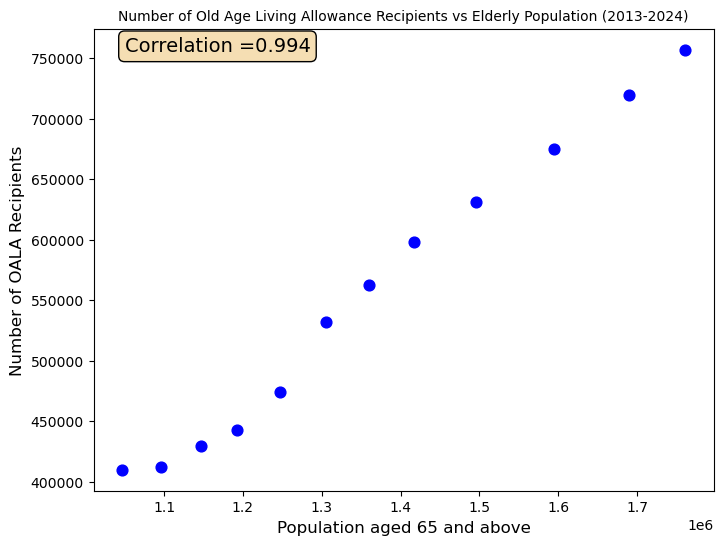

In [379]:
Correlation = df['Persons_Receiving_OALA'].corr(df['Population_aged_65_and_above'])

# Create a scatter plot
plt.figure(figsize=(8,6))
plt.scatter(df['Population_aged_65_and_above'], df['Persons_Receiving_OALA'],color='blue', s=60)

# Add correlation as legend on the graph
plt.text(0.05, 0.95, f'Correlation ={correlation:.3f}',
         transform= plt.gca().transAxes, fontsize=14, 
         bbox= dict(boxstyle='round,pad=0.3', facecolor='wheat'))

# Add text labels and title
plt.xlabel('Population aged 65 and above', fontsize=12)
plt.ylabel('Number of OALA Recipients', fontsize=12)
plt.title('Number of Old Age Living Allowance Recipients vs Elderly Population (2013-2024)', fontsize= 10)

plt.show()


With a correlation coefficient of 0.994, this chart powerfully demonstrates that the greater Hong Kong's population aged 65 and above, the greater the number of OALA recipients. This relationship reflects the direct impact of population aging on social welfare expenditure.

In [381]:
# Create a DataFrame with phase averages
phase_data = pd.DataFrame({
    'Phase': ['2013-2017\n(Normal OALA only)', 
              '2018-2021\n(Normal + Higher OALA)', 
              '2022-2024\n(Unified OALA)'],
    'Average_Recipients': [433765, 581089, 717226] # Average Number of OALA Recipients by Policy Phase (2013–2017)= (410,043+412,291+429,244+442,932+474,315)/5 = 433,765
                                                   # Average Number of OALA Recipients by Policy Phase (2018-2021)= (532,500+563,014+597,883+630,961)/4 = 581,089
                                                   # Average Number of OALA Recipients by Policy Phase (2022-2024)= 674,735+719,873+757,071)/3 = 717,226
})

In [385]:
phase_data

,Phase,Average_Recipients
0,2013-2017\n(Normal OALA only),433765
1,2018-2021\n(Normal + Higher OALA),581089
2,2022-2024\n(Unified OALA),717226


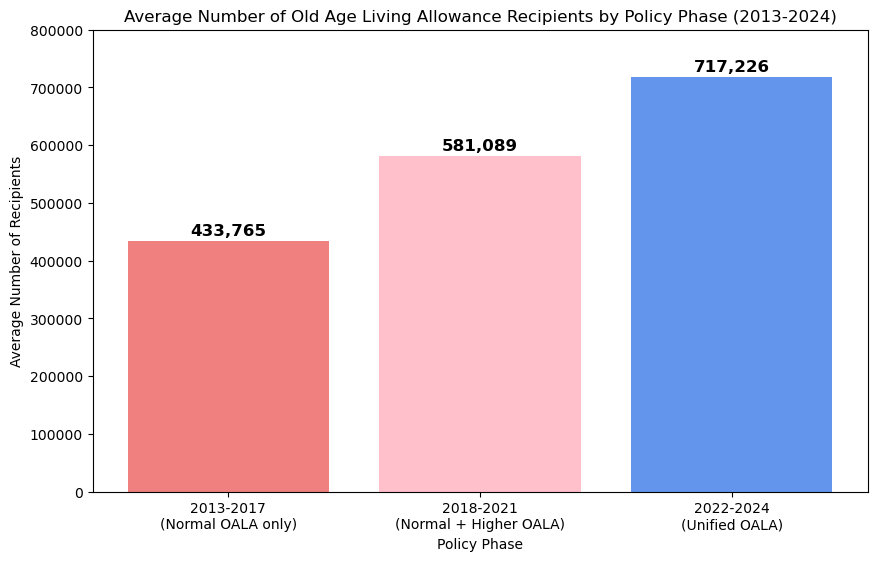

In [404]:
plt.figure(figsize=(10,6))

# Add color of each bar
colors =['lightcoral', 'pink', 'cornflowerblue']

#Create a bar chart
bars = plt.bar(phase_data['Phase'], phase_data['Average_Recipients'], color=colors)

# Add data labels
for bar in bars:
    height= bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height+ 10000,
    f"{int(height):,}", ha= 'center', fontsize= 12, fontweight= 'bold')

# Add text labels and title
plt.title('Average Number of Old Age Living Allowance Recipients by Policy Phase (2013-2024)')
plt.ylabel('Average Number of Recipients')
plt.xlabel('Policy Phase')
plt.ylim(0, 800000)

plt.show()

The bar chart shows a upward trend. The average number of recipients increased from 433,765 in 2013‑2017 to 581,089 in 2018‑2021 with Normal and Higher Old Age Living Allowance adopted. It shows that there is a rise of 34.0%. In 2022‑2024 with Unified Old Age Living Allowance adopted,  the average number of recipients increased to 717,226. It shows that there is 23.4% increase from 2018-2021. It reflects that policy expansions which is the implementation of Higher Old Age Living Allowanc and later become unified have led to to the growing number of recipients.

In [452]:
df = pd.read_csv("Project/OALA_history.csv")
df

,OALA_history,Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4,Unnamed: 5
0,Effective_Date,Allowance_Type,Monthly_Amount_HKD,Asset_Limit_Single_HKD,Asset_Limit_Couple_HKD,Event_Notes
1,2012-12-01,OALA,2200,NaN,NaN,Scheme effective date (retroactive); limits an...
2,2013-04-01,OALA,2200,193000,292000,Scheme formally launched
3,2014-02-01,OALA,2285,201000,304000,First adjustment based on price index; subsequ...
4,2015-02-01,OALA,2390,210000,318000,Annual adjustment
5,2016-02-01,OALA,2495,219000,332000,Annual adjustment
6,2017-02-01,OALA,2565,225000,341000,Annual adjustment
7,2017-05-01,Normal_OALA,2565,329000,499000,Original allowance renamed Normal rate; asset ...
8,2017-05-01,Higher_OALA,3435,144000,218000,Introduction of Higher Old Age Living Allowanc...
9,2018-02-01,Normal_OALA,2600,334000,506000,Annual adjustment


The Hong Kong Composite Consumer Price Index (CPI) typically uses 2014 as the base period. The Old Age Living Allowance in 2014 aligns with the base period of the official price index. In 2014, only the Normal Old Age Living Allowance existed but the Higher Old Age Living Allowance did not exist and could not serve as a starting point.


In [453]:
# Build the data (using 2014 as base year, CPI = 100)
data = {
    'Year': [2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
    'Amount_of_Old_Age_Living_Allowance': [2285, 2390, 2495, 2565, 2600, 2675, 2690, 2845, 2920, 4060, 4195],
    'CPI': [100.0, 103.0, 106.0, 108.5, 111.0, 113.5, 115.0, 117.5, 119.0, 120.5, 121.5] # New‑base CPI = (Original CPI / Original CPI in 2014) × 100
}

In [454]:
# Convert to DataFrame
df = pd.DataFrame(data)
print("Raw data:")
print(df)

Raw data:
    Year  Amount_of_Old_Age_Living_Allowance    CPI
0   2014                                2285  100.0
1   2015                                2390  103.0
2   2016                                2495  106.0
3   2017                                2565  108.5
4   2018                                2600  111.0
5   2019                                2675  113.5
6   2020                                2690  115.0
7   2021                                2845  117.5
8   2022                                2920  119.0
9   2023                                4060  120.5
10  2024                                4195  121.5


In [455]:
# Calculate cumulative percentage change (base = 2014)
base_oala = df['Amount_of_Old_Age_Living_Allowance'].iloc[0]
base_cpi = df['CPI'].iloc[0]

df['Old_Age_Living_Allowance_Cumul_Pct'] = ((df['Amount_of_Old_Age_Living_Allowance'] - base_oala) / base_oala) * 100
df['CPI_Cumul_Pct'] = ((df['CPI'] - base_cpi) / base_cpi) * 100

In [456]:
# Generate Table A-1: Allowance cumulative increase vs overall inflation
table_a1 = df[['Year', 'Amount_of_Old_Age_Living_Allowance', 'CPI', 'Old_Age_Living_Allowance_Cumul_Pct', 'CPI_Cumul_Pct']].copy()
table_a1.columns= ['Year', 'Allowance Amount (HKD)', 'CPI (2014=100)', 'Allowance Cumulative %', 'Inflation Cumulative %']

print('Table A-1; Old Age Living Allowance Cumulative Increase vs Overall Inflation')
print(table_a1.to_string(index= False))

Table A-1; Old Age Living Allowance Cumulative Increase vs Overall Inflation
 Year  Allowance Amount (HKD)  CPI (2014=100)  Allowance Cumulative %  Inflation Cumulative %
 2014                    2285           100.0                0.000000                     0.0
 2015                    2390           103.0                4.595186                     3.0
 2016                    2495           106.0                9.190372                     6.0
 2017                    2565           108.5               12.253829                     8.5
 2018                    2600           111.0               13.785558                    11.0
 2019                    2675           113.5               17.067834                    13.5
 2020                    2690           115.0               17.724289                    15.0
 2021                    2845           117.5               24.507659                    17.5
 2022                    2920           119.0               27.789934        

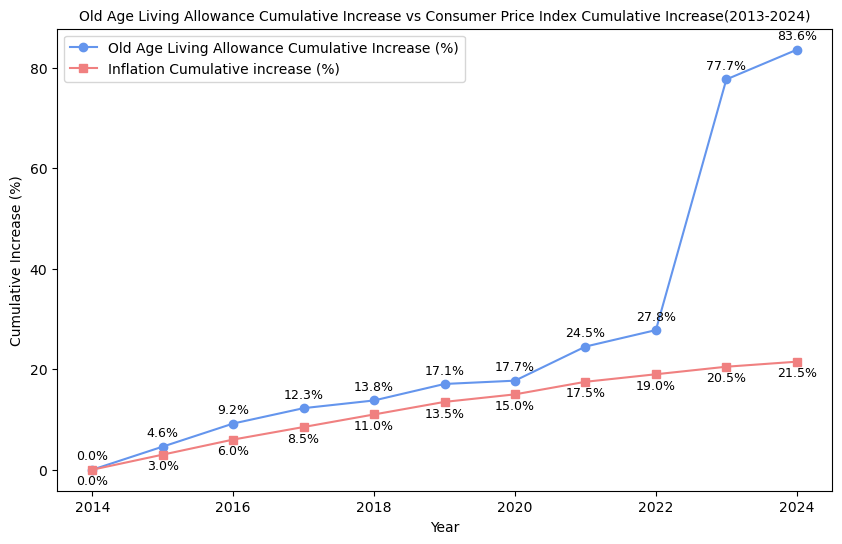

In [462]:
# Create a line plot
plt.figure(figsize=(10,6))

# Add text labels and title
plt.xlabel('Year')
plt.ylabel('Cumulative Increase (%)')
plt.title('Old Age Living Allowance Cumulative Increase vs Consumer Price Index Cumulative Increase(2013-2024)', fontsize = 10)

# Plot the first line: Old Age Living Allowance cumulative increase
plt.plot(df['Year'], df['Old_Age_Living_Allowance_Cumul_Pct'], marker= 'o', color= 'cornflowerblue', label= 'Old Age Living Allowance Cumulative Increase (%)')

# Plot the second line: Inflation cumulative increase (CPI)
plt.plot(df['Year'], df['CPI_Cumul_Pct'], marker= 's', color= 'lightcoral', label= 'Inflation Cumulative increase (%)')

# Add legends
plt.legend()

# Add data labels
for i in range(len(df)):
    plt.text(df['Year'][i], df['Old_Age_Living_Allowance_Cumul_Pct'][i]+2, f"{df['Old_Age_Living_Allowance_Cumul_Pct'][i]:.1f}%", ha='center', fontsize=9) 
    plt.text(df['Year'][i], df['CPI_Cumul_Pct'][i]-3, f"{df['CPI_Cumul_Pct'][i]:.1f}%", ha='center', fontsize=9)
    
plt.show()


The dual line chart shows that trend of the OALA cumulative increase that is 83.6% is higher than the inflation cumulative increase. The improvement of real purchasing power of the Old Age Living Allowance is considerable. In other words, the price changes is not the driving factor for the growing number of Old Age Living Allowance recipients. The soaring number of the recipients is affected by the ageing populations and Old Age Living Allowance policy reforms. 

=====================AI Disclosure====================

AI tool used: Deepseek and Chat GPT

Specific purposes:

1. Adding codes for detials in the graphs(colors, frontsize, labels)

2. Suming up the total elderly population and recipents from extracting data in csv documents

3. Suggestion for work division

4. Summarize the history of monthly amount and asset limit for single and couple regarding Old Age Living Allowance into a table.

5. Debugging code

I have reviewed, tested, and fully understand all code/output, including AI-assisted parts. I take responsibility for the final work.